#Projeto de Aprendizado de Máquina em Bioinformática
Aluna: Gabriela Neres de Oliveira e Silva

# INTRODUÇÃO

O Transtorno do Espectro Autista (TEA) é um transtorno de neurodesenvolvimento caracterizado por causar dificuldades na comunicação e interação social, bem como comportamento esteriotipado e padrões repetitivos. Sabe-se ainda que muitas crianças com TEA apresentam uma série de problemas gastrointestinais, tais como diarreia, constipação, entre outros. Como muitos problemas gastrointestinais estão relacionados com a microbiota desse sistema fisiológico, então há várias pesquisas que tentam analisar se há alguma relação do TEA com a microbiota intestinal.

Algumas pesquisas mostram que alterações na microbiota intestinal podem impactar o neurodesenvolvimento. Além disso, muitos microorganismos intestinais têm a capacidade de produzir neurotransmissores, que podem impactar o funcionamento do sistema nervoso. Atualmente, sabemos que a microbiota tem grande influência nos nossos comportamentos, mas isso pode nos dizer algo sobre o TEA?

Com base nisso, minha pergunta é: Quais os microorganismos decisivos, se houver, para diferenciar uma criança com TEA de uma criança com desenvolvimento típico?

Portanto, o objetivo do meu projeto é analisar um dataset do artigo “Altered gut microbial profile is associated with abnormal metabolism activity of Autism Spectrum Disorder” buscando encontrar padrões nos grupos de microrganismos que compõem a microbiota de pessoas com TEA.

# MATERIAIS

O dataset utilizado no projeto pode ser encontrado no site Kaggle sob o título de "Human gut microbiome of the children with ASD". Esse dataset tem como origem principal o artigo "Altered gut microbial profile is associated with abnormal metabolism activity of Autism Spectrum Disorder" dos autores Zhou Dan et al. (2020).

Os dados metagenômicos foram obtidos a partir de amostras fecais de 30 crianças com TEA que apresentavam constipação e 30 crianças com desenvolvimento típico da mesma faixa etária.

As observações do dataset consistem em 30 crianças com TEA e 30 crianças com desenvolvimento típico, logo são 2 observações. As variáveis são representadas pelas espécies encontradas na microbiota intestinal pelos autores do artigo.

# MÉTODOS E RESULTADOS

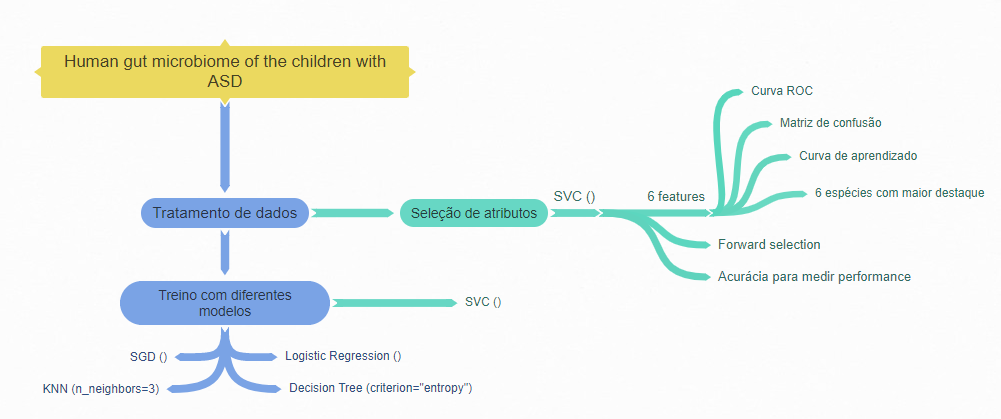

In [ ]:
#importando bibliotecas
import pandas as pd
import numpy as np

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import learning_curve

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import plot_roc_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
import joblib
import sys
sys.modules['sklearn.externals.joblib'] = joblib
import matplotlib.pyplot as plt
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

In [ ]:
url = '/content/ASD meta abundance.csv'
#columns = ['Class','id','Sequence'] # Nomeando as colunas
table = pd.read_csv(url, delimiter=',') # lendo os dados

Inicialmente retiro a linhas que não tem valor algum.

In [ ]:
table = table[table.sum(axis = 1) !=0]
table

<ipython-input-8-b8497abf7536>:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  table = table[table.sum(axis = 1) !=0]


,Taxonomy,A3,A5,A6,A9,A31,A51,A52,A53,A54,...,B120,B127,B132,B141,B142,B143,B152,B156,B158,B164
0,g__Faecalibacterium;s__Faecalibacterium prausn...,4988,5060,2905,5745,4822,3889,4646,6337,5064,...,4471,5868,6561,4910,4492,2812,5303,4205,3430,4563
1,g__Hungatella;s__Hungatella hathewayi,5803,5612,4109,1432,2652,4175,3891,894,4903,...,2126,4429,2598,4222,4925,5753,1261,1822,2478,4868
2,g__Clostridium;s__uncultured Clostridium sp.,3793,2795,1355,5558,5383,3505,5541,4429,4121,...,4085,6041,6188,3960,4403,2841,2746,3808,3856,3211
3,g__Butyricimonas;s__Butyricimonas virosa,64,1385,725,1553,40,53,33,175,58,...,2065,21,27,55,35,8,884,13,3,218
4,g__Alistipes;s__Alistipes indistinctus,15,20,723,620,3261,43,83,37,43,...,90,22,30,1027,2641,4,1587,2223,6,1473
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5452,g__Unclassified;s__Skermania phage SPI1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5453,g__Unclassified;s__Vibrio phage vB_VhaS-tm,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
5454,g__Unclassified;s__uncultured Mediterranean ph...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5455,g__Unclassified;s__uncultured Mediterranean ph...,0,0,0,1,0,0,0,0,0,...,0,1,1,0,0,0,0,0,0,0


In [ ]:
table = table.transpose()
table

,0,1,2,3,4,5,6,7,8,9,...,5447,5448,5449,5450,5451,5452,5453,5454,5455,5456
Taxonomy,g__Faecalibacterium;s__Faecalibacterium prausn...,g__Hungatella;s__Hungatella hathewayi,g__Clostridium;s__uncultured Clostridium sp.,g__Butyricimonas;s__Butyricimonas virosa,g__Alistipes;s__Alistipes indistinctus,g__Unclassified;s__Firmicutes bacterium CAG:176,g__Clostridium;s__Clostridium sp. CAG:7,g__Unclassified;s__Firmicutes bacterium CAG:882,g__Lachnoclostridium;s__[Clostridium] asparagi...,g__Butyricicoccus;s__uncultured Butyricicoccus...,...,g__Unclassified;s__Deep-sea thermophilic phage...,g__Unclassified;s__Environmental Halophage eHP-30,g__Unclassified;s__Flavobacterium phage FKj-2,g__Unclassified;s__Geobacillus virus E2,g__Unclassified;s__Salmonella phage 64795_sal3,g__Unclassified;s__Skermania phage SPI1,g__Unclassified;s__Vibrio phage vB_VhaS-tm,g__Unclassified;s__uncultured Mediterranean ph...,g__Unclassified;s__uncultured Mediterranean ph...,g__Unclassified;s__uncultured virus
A3,4988,5803,3793,64,15,100,2119,12,453,1266,...,0,0,0,0,0,0,0,0,0,0
A5,5060,5612,2795,1385,20,29,1230,24,691,1682,...,0,0,0,0,0,0,0,0,0,0
A6,2905,4109,1355,725,723,11,1322,1,2278,43,...,0,0,0,0,0,0,0,0,0,0
A9,5745,1432,5558,1553,620,1320,2675,44,107,1726,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B143,2812,5753,2841,8,4,10,180,46,1508,1069,...,0,1,0,0,0,0,0,0,0,0
B152,5303,1261,2746,884,1587,28,2134,19,1169,1226,...,0,0,0,0,0,0,0,0,0,0
B156,4205,1822,3808,13,2223,38,1134,25,321,1601,...,0,0,0,0,0,0,0,0,0,0
B158,3430,2478,3856,3,6,15,1487,47,2169,839,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
taxonomy = table.iloc[0].values.tolist()
taxonomy

['g__Faecalibacterium;s__Faecalibacterium prausnitzii',
 'g__Hungatella;s__Hungatella hathewayi',
 'g__Clostridium;s__uncultured Clostridium sp.',
 'g__Butyricimonas;s__Butyricimonas virosa',
 'g__Alistipes;s__Alistipes indistinctus',
 'g__Unclassified;s__Firmicutes bacterium CAG:176',
 'g__Clostridium;s__Clostridium sp. CAG:7',
 'g__Unclassified;s__Firmicutes bacterium CAG:882',
 'g__Lachnoclostridium;s__[Clostridium] asparagiforme',
 'g__Butyricicoccus;s__uncultured Butyricicoccus sp.',
 'g__Unclassified;s__Firmicutes bacterium CAG:95',
 'g__Oscillibacter;s__Oscillibacter sp. ER4',
 'g__Desulfovibrio;s__Desulfovibrio piger',
 'g__Fusobacterium;s__Fusobacterium mortiferum',
 'g__Clostridium;s__Clostridium sp. GD3',
 'g__Unclassified;s__Firmicutes bacterium CAG:124',
 'g__Unclassified;s__Burkholderiales bacterium YL45',
 'g__Ruminococcus;s__Ruminococcus callidus',
 'g__Flavonifractor;s__uncultured Flavonifractor sp.',
 'g__Subdoligranulum;s__Subdoligranulum variabile',
 'g__Clostridium

In [ ]:
table = table.drop(['Taxonomy'])
table

,0,1,2,3,4,5,6,7,8,9,...,5447,5448,5449,5450,5451,5452,5453,5454,5455,5456
A3,4988,5803,3793,64,15,100,2119,12,453,1266,...,0,0,0,0,0,0,0,0,0,0
A5,5060,5612,2795,1385,20,29,1230,24,691,1682,...,0,0,0,0,0,0,0,0,0,0
A6,2905,4109,1355,725,723,11,1322,1,2278,43,...,0,0,0,0,0,0,0,0,0,0
A9,5745,1432,5558,1553,620,1320,2675,44,107,1726,...,0,0,0,0,0,0,0,0,1,0
A31,4822,2652,5383,40,3261,51,1470,26,342,1804,...,0,0,0,0,0,0,0,0,0,0
A51,3889,4175,3505,53,43,45,2262,9,1304,1441,...,0,0,0,0,0,0,0,0,0,0
A52,4646,3891,5541,33,83,52,2984,25,1400,2691,...,0,0,0,0,0,0,0,0,0,0
A53,6337,894,4429,175,37,64,2004,19,1207,1886,...,0,0,0,0,0,0,0,0,0,0
A54,5064,4903,4121,58,43,60,1904,17,2034,919,...,0,0,1,0,1,0,0,0,0,0
A59,6359,2970,3258,1636,1114,896,1227,17,2051,2215,...,0,0,0,0,0,0,0,0,1,1


Rótulos: 1 para crianças com TEA e 0 para crianças sem TEA.

In [ ]:
target = table.index.to_list()
new_target = np.array([1 if t.startswith('A') else 0 for t in target ])
new_target

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
table['total'] = table.sum(axis=1)
table = table.pipe(lambda x: x.div(x['total'], axis='index'))
table

,0,1,2,3,4,5,6,7,8,9,...,5448,5449,5450,5451,5452,5453,5454,5455,5456,total
A3,0.067775,0.078849,0.051538,0.00087,0.000204,0.001359,0.028792,0.000163,0.006155,0.017202,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
A5,0.058436,0.06481,0.032278,0.015995,0.000231,0.000335,0.014205,0.000277,0.00798,0.019425,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
A6,0.049958,0.070663,0.023302,0.012468,0.012434,0.000189,0.022735,0.000017,0.039175,0.000739,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
A9,0.048925,0.012195,0.047332,0.013225,0.00528,0.011241,0.02278,0.000375,0.000911,0.014699,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000009,0.0,1.0
A31,0.050381,0.027709,0.056243,0.000418,0.034072,0.000533,0.015359,0.000272,0.003573,0.018849,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
A51,0.058046,0.062314,0.052314,0.000791,0.000642,0.000672,0.033762,0.000134,0.019463,0.021508,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
A52,0.053166,0.044527,0.063408,0.000378,0.00095,0.000595,0.034147,0.000286,0.016021,0.030794,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
A53,0.06748,0.00952,0.047162,0.001863,0.000394,0.000682,0.02134,0.000202,0.012853,0.020083,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
A54,0.049234,0.047669,0.040066,0.000564,0.000418,0.000583,0.018511,0.000165,0.019775,0.008935,...,0.0,0.00001,0.0,0.00001,0.0,0.0,0.0,0.0,0.0,1.0
A59,0.060168,0.028102,0.030827,0.01548,0.010541,0.008478,0.01161,0.000161,0.019406,0.020958,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000009,0.000009,1.0


A tabela acima é a tabela final após todos os tratamentos de dados. A última modificação realizada consiste em converter os dados inteiros em dados referentes à porcentagem de cada espécie nos respectivos indivíduos.

##TREINO

In [ ]:
del table['total']
table

,0,1,2,3,4,5,6,7,8,9,...,5447,5448,5449,5450,5451,5452,5453,5454,5455,5456
A3,0.067775,0.078849,0.051538,0.00087,0.000204,0.001359,0.028792,0.000163,0.006155,0.017202,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A5,0.058436,0.06481,0.032278,0.015995,0.000231,0.000335,0.014205,0.000277,0.00798,0.019425,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A6,0.049958,0.070663,0.023302,0.012468,0.012434,0.000189,0.022735,0.000017,0.039175,0.000739,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A9,0.048925,0.012195,0.047332,0.013225,0.00528,0.011241,0.02278,0.000375,0.000911,0.014699,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000009,0.0
A31,0.050381,0.027709,0.056243,0.000418,0.034072,0.000533,0.015359,0.000272,0.003573,0.018849,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A51,0.058046,0.062314,0.052314,0.000791,0.000642,0.000672,0.033762,0.000134,0.019463,0.021508,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A52,0.053166,0.044527,0.063408,0.000378,0.00095,0.000595,0.034147,0.000286,0.016021,0.030794,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A53,0.06748,0.00952,0.047162,0.001863,0.000394,0.000682,0.02134,0.000202,0.012853,0.020083,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A54,0.049234,0.047669,0.040066,0.000564,0.000418,0.000583,0.018511,0.000165,0.019775,0.008935,...,0.0,0.0,0.00001,0.0,0.00001,0.0,0.0,0.0,0.0,0.0
A59,0.060168,0.028102,0.030827,0.01548,0.010541,0.008478,0.01161,0.000161,0.019406,0.020958,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000009,0.000009


In [ ]:
#dados de treino e teste

X_train,X_test,y_train,y_test = train_test_split(table, new_target, test_size=0.3, random_state=1234, shuffle = True)

In [ ]:
# KNN

knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

In [ ]:
# SGD

sgd_model = SGDClassifier()
sgd_model.fit(X_train, y_train)
y_pred_sgd = sgd_model.predict(X_test)

In [ ]:
# Regressão Logística

log_model = LogisticRegression()
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

In [ ]:
# SVC

svc_model = SVC()
svc_model.fit(X_train, y_train)
y_pred_svc = svc_model.predict(X_test)

In [ ]:
#DecisionTree

tree_model = DecisionTreeClassifier(criterion="entropy")
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

In [ ]:
targets = ["1","0"]

print("KNN")
print(classification_report(y_test, y_pred_knn, target_names=targets))  # knn classification report

print("SGD")
print(classification_report(y_test, y_pred_sgd, target_names=targets))  # sgd classification report

print("Logistic regression")
print(classification_report(y_test, y_pred_log, target_names=targets))  # logistic classification report

print("SVC")
print(classification_report(y_test, y_pred_svc, target_names=targets))  # svc report

print("Decision Tree")
print(classification_report(y_test, y_pred_tree, target_names=targets))  # decision tree report

KNN
              precision    recall  f1-score   support

           1       0.43      0.38      0.40         8
           0       0.55      0.60      0.57        10

    accuracy                           0.50        18
   macro avg       0.49      0.49      0.49        18
weighted avg       0.49      0.50      0.50        18

SGD
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         8
           0       0.56      1.00      0.71        10

    accuracy                           0.56        18
   macro avg       0.28      0.50      0.36        18
weighted avg       0.31      0.56      0.40        18

Logistic regression
              precision    recall  f1-score   support

           1       0.44      1.00      0.62         8
           0       0.00      0.00      0.00        10

    accuracy                           0.44        18
   macro avg       0.22      0.50      0.31        18
weighted avg       0.20      0.44      0.27   

/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classificat

Os modelos com maior acurácia foram Decision Tree e SVC. O modelo SVC foi escolhido para dar prosseguimento à análise dos dados.

In [ ]:
#matriz de confusão

cm = confusion_matrix(y_test, y_pred_svc) # fornecer o rótulo e as predições do conjunto teste
cm
#[TN, FP]
#[FN, TP]

array([[5, 3],
       [3, 7]])

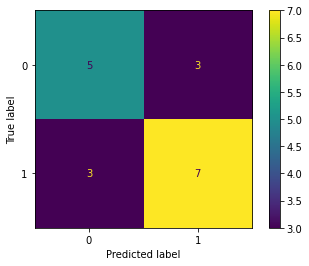

In [ ]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["0","1"]
)

disp.plot()

plt.show()

A imagem acima representa a predição dada pelo modelo escolhido com uma matriz de confusão, pode-se observar que ainda há falsos positivos e falsos negativos.

##SELEÇÃO DE ATRIBUTOS

In [ ]:
#nomes de atributos em uma lista
feature_names = table.columns.tolist()
feature_names

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 184,


In [ ]:
#seleção de atributos por forward selection
model = SVC()

# Forward selection
sfs1 = SFS(model,
           k_features=(1,10), # número de atributos a ser selecionado. Colocar "best" para selecionar a melhor combinação.
           forward=True,      # False para backward
           floating=False,    # True para combinar forward e backward
           verbose=2,
           scoring='accuracy',# métrica para medir a performance
           cv=4,              # k-fold cross-validation
           #n_jobs=4           # número de processadores
           )

# Executando o forward selection
sfs1 = sfs1.fit(table,  # dados
                new_target,    # variável resposta
                custom_feature_names=list(feature_names) # nomes dos atributos
                )

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=1)]: Done 5457 out of 5457 | elapsed:   33.7s finished

[2022-12-20 15:26:33] Features: 1/10 -- score: 0.8499999999999999[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done 5456 out of 5456 | elapsed:   36.6s finished

[2022-12-20 15:27:10] Features: 2/10 -- score: 0.9333333333333333[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done 5455 out of 5455 | elapsed:   49.0s finished

[2022-12-20 15:27:59] Features: 3/10 -- score: 0.9666666666666668[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: 

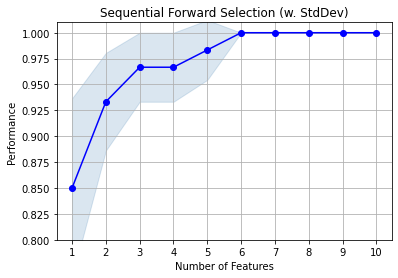

In [ ]:
# Gráfico da performance do classificador ao longo da iteração
fig1 = plot_sfs(sfs1.get_metric_dict(), kind='std_dev')

plt.ylim([0.8, 1.01])
plt.title('Sequential Forward Selection (w. StdDev)')
plt.grid()
plt.show()

O gráfico acima nos mostra que a partir do 6º atributo o modelo alcança uma perfomance de 1.00, medida pela acurácia.

In [ ]:
data = table.iloc[:, list(sfs1.k_feature_idx_)]

# Verificando a performance do classificador utilizando apenas os atributos selecionados
clf = SVC()
scores = cross_val_score(clf, data, new_target, cv=4)
print("Accuracy: %0.4f (+/- %0.4f)" % (scores.mean(), scores.std() * 2))
data

Accuracy: 1.0000 (+/- 0.0000)


,776,913,1420,1549,1693,2439
A3,0.000041,0.000014,0.0,0.000014,0.000014,0.000027
A5,0.000081,0.000012,0.000035,0.000046,0.0,0.0
A6,0.000034,0.000017,0.000017,0.000052,0.0,0.0
A9,0.000026,0.000009,0.000009,0.000026,0.000034,0.0
A31,0.00001,0.000031,0.00001,0.000021,0.0,0.0
A51,0.00003,0.000045,0.00003,0.000045,0.0,0.0
A52,0.000011,0.000023,0.000023,0.000011,0.000011,0.0
A53,0.0,0.000064,0.000053,0.000021,0.000011,0.0
A54,0.00001,0.000029,0.000029,0.000019,0.0,0.0
A59,0.000009,0.000123,0.0,0.000038,0.0,0.0


Na tabela acima pode-se observar quais os valores que representam os atributos selecionados.

In [ ]:
micro = []
for i in range(len(taxonomy)):
  if i in list(sfs1.k_feature_idx_):
    micro.append(taxonomy[i])
micro

['g__Bacteroides;s__Bacteroides sp. CAG:545',
 'g__Porphyromonas;s__Porphyromonas macacae',
 'g__Mucilaginibacter;s__Mucilaginibacter paludis',
 'g__Dysgonomonas;s__Dysgonomonas sp. HGC4',
 'g__Micavibrio;s__Micavibrio aeruginosavorus',
 'g__Bacillus;s__Bacillus velezensis']

Neste vetor vemos listados as espécies mas significantes para predição.

In [ ]:
X_train1,X_test1,y_train1,y_test1 = train_test_split(data, new_target, test_size=0.3, random_state=1234)


In [ ]:
model_features = SVC()
model_features.fit(X_train1, y_train1)
y_pred_features = model_features.predict(X_test1)

In [ ]:
print("SVC")
print(classification_report(y_test1, y_pred_features, target_names=targets))

SVC
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         8
           0       1.00      1.00      1.00        10

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



Note na tabela acima que o modelo treinado com a tabela nova de 6 atributos tem uma performance muito boa na classificação.

In [ ]:
cm = confusion_matrix(y_test1, y_pred_features) # fornecer o rótulo e as predições do conjunto teste
cm

array([[ 8,  0],
       [ 0, 10]])

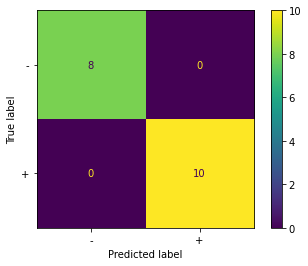

In [ ]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["-","+"]
)

disp.plot()

plt.show()

Nova matriz de confusão baseada na tabela de 6 atributos, perceba que não há mais falsos positivos nem falsos negativos, como acontecia antes da seleção de atributos.

In [ ]:
train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(model_features, data, new_target, cv=10,return_times=True)

In [ ]:
# Calculate training and test mean and std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

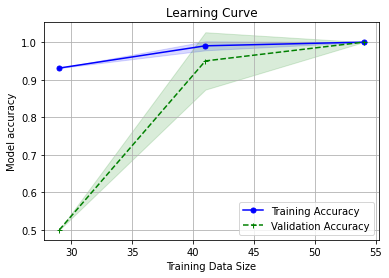

In [ ]:
# Plot the learning curve

plt.plot(train_sizes, train_mean, color='blue', marker='o', markersize=5, label='Training Accuracy')
plt.fill_between(train_sizes, train_mean + train_std, train_mean - train_std, alpha=0.15, color='blue')
plt.plot(train_sizes, test_mean, color='green', marker='+', markersize=5, linestyle='--', label='Validation Accuracy')
plt.fill_between(train_sizes, test_mean + test_std, test_mean - test_std, alpha=0.15, color='green')
plt.title('Learning Curve')
plt.xlabel('Training Data Size')
plt.ylabel('Model accuracy')
plt.grid()
plt.legend(loc='lower right')
plt.show()

O gráfico da curva de aprendizagem mostra que não há overfitting nem underfitting.

/usr/local/lib/python3.8/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_roc_curve is deprecated; Function :func:`plot_roc_curve` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: :meth:`sklearn.metric.RocCurveDisplay.from_predictions` or :meth:`sklearn.metric.RocCurveDisplay.from_estimator`.
  warnings.warn(msg, category=FutureWarning)


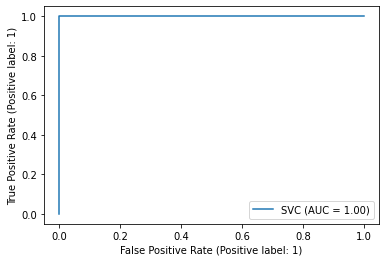

In [ ]:
plot_roc_curve(model_features, X_test1, y_test1)

Curva ROC apresentando a perfomance do modelo na tabela com 6 atributos.

# DISCUSSÃO


O modelo de aprendizado de máquina utilizado identificou que 6 atributos (espécies) são importantes para classificar uma criança com TEA ou não. Estas espécies foram *Bacteroides sp.*, *Porphyromas macacae*, *Mucilaginibacter paludis*, *Dysgonomonas sp.*, *Micavibrio aeruginosavoru* e *Bacillus velezensis*.

De acordo com Zhou Dan et al. (2020) e Rong Zou et al. (2020), as crianças com autismo apresentaram uma baixa nas espécies *Bacteroides sp.* em todas as idades, diferentemente das crianças com desenvolvimento típico, que tinham aumento da espécie seguido de uma baixa. Em contrapartida, os trabalhos de Ahmed, S.A. et al.(2020) e Iglesias-Vázquez, L. et al. (2020), mostram que o gênero *Bacteroides* na verdade está em alta em crianças com TEA. De qualquer forma, estando em alta ou baixa, o gênero parece ter uma forte relação com o TEA. Assim, esse gênero de bactérias pode estar relacionado com alguns neurotransmissores, como afirma o trabalho de Zhou Dan et al. (2020). No trabalho de Zhi Liu et al. (2021), percebeu-se ainda que a presença de espécies do gênero *Bacteroides* está relacionada com variações em genes imuno-relacionados.

As outras espécies não são citadas na literatura no que diz respeito ao estudo do TEA, isso pode significar que o modelo produzido não é o ideal para classificação do transtorno. Para contornar essa situação é necessário que haja um estudo dos parâmetros ideias para o modelo.

#REFERÊNCIAS

AHMED, Shwikar Abdelsalam; ELHEFNAWY, Azza Mahmoud; AZOUZ, Hanan Galal; ROSHDY, Yara Safwat; ASHRY, Mona Hamdy; IBRAHIM, Ahmed Elsayed; MEHEISSEN, Marwa Ahmed. Study of the gut Microbiome Profile in Children with Autism Spectrum Disorder: a single tertiary hospital experience. **Journal Of Molecular Neuroscience**, [S.L.], v. 70, n. 6, p. 887-896, 15 fev. 2020. Springer Science and Business Media LLC. http://dx.doi.org/10.1007/s12031-020-01500-3.

DAN, Zhou; MAO, Xuhua; LIU, Qisha; GUO, Mengchen; ZHUANG, Yaoyao; LIU, Zhi; CHEN, Kun; CHEN, Junyu; XU, Rui; TANG, Junming. Altered gut microbial profile is associated with abnormal metabolism activity of Autism Spectrum Disorder. **Gut Microbes**, [S.L.], v. 11, n. 5, p. 1246-1267, 21 abr. 2020. Informa UK Limited. http://dx.doi.org/10.1080/19490976.2020.1747329.

IGLESIAS-VÁZQUEZ, Lucía; RIBA, Georgette van Ginkel; ARIJA, Victoria; CANALS, Josefa. Composition of Gut Microbiota in Children with Autism Spectrum Disorder: a systematic review and meta-analysis. **Nutrients**, [S.L.], v. 12, n. 3, p. 792, 17 mar. 2020. MDPI AG. http://dx.doi.org/10.3390/nu12030792.

LIU, Zhi; MAO, Xuhua; DAN, Zhou; PEI, Yang; XU, Rui; GUO, Mengchen; LIU, Kangjian; ZHANG, Faming; CHEN, Junyu; SU, Chuan. Gene variations in Autism Spectrum Disorder are associated with alternation of gut microbiota, metabolites and cytokines. **Gut Microbes**, [S.L.], v. 13, n. 1, p. 1-16, 1 jan. 2021. Informa UK Limited. http://dx.doi.org/10.1080/19490976.2020.1854967.

ZOU, Rong; XU, Fenfen; WANG, Yuezhu; DUAN, Mengmeng; GUO, Min; ZHANG, Qiang; ZHAO, Hongyang; ZHENG, Huajun. Changes in the Gut Microbiota of Children with Autism Spectrum Disorder. **Autism Research**, [S.L.], v. 13, n. 9, p. 1614-1625, 24 ago. 2020. Wiley. http://dx.doi.org/10.1002/aur.2358.